In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset from Project 01
df = pd.read_excel('cleaned_dataset_Elham-Azari.xlsx')  

# Calculate AOV (Average Order Value)
df['aov'] = df['total_spending'] / df['purchase_count']

# General KPIs
total_customers = df['customer_id'].nunique()
total_revenue = df['total_spending'].sum()
avg_spend = df['total_spending'].mean()
avg_aov = df['aov'].mean()

print(f"Total Customers: {total_customers}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Spend per Customer: ${avg_spend:,.2f}")
print(f"Average Order Value (AOV): ${avg_aov:,.2f}")

Total Customers: 60
Total Revenue: $201,985.73
Average Spend per Customer: $3,366.43
Average Order Value (AOV): $215.69


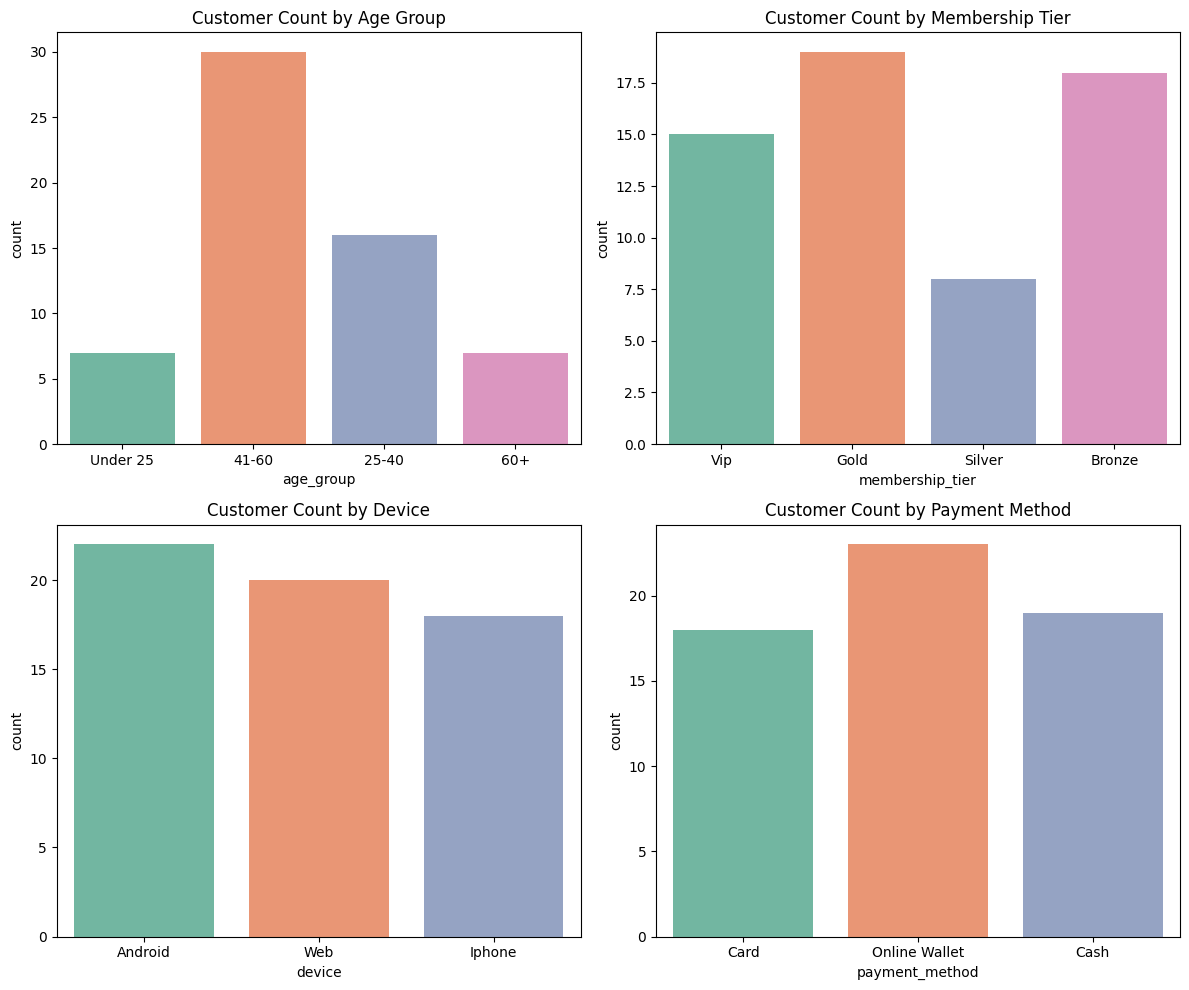

In [2]:
# Age Group Segmentation
def categorize_age(age):
    if age < 25: return 'Under 25'
    elif 25 <= age <= 40: return '25-40'
    elif 41 <= age <= 60: return '41-60'
    else: return '60+'

df['age_group'] = df['age'].apply(categorize_age)

# Plots for Demographics
# Task 1: Demographics Plot (Fixed Warnings)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x='age_group', hue='age_group', ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Customer Count by Age Group')

sns.countplot(data=df, x='membership_tier', hue='membership_tier', ax=axes[0,1], palette='Set2', legend=False)
axes[0,1].set_title('Customer Count by Membership Tier')

sns.countplot(data=df, x='device', hue='device', ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Customer Count by Device')

sns.countplot(data=df, x='payment_method', hue='payment_method', ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Customer Count by Payment Method')

plt.tight_layout()
plt.show()

,province,city,total_revenue,customer_count,avg_spending,purchase_count,avg_aov,avg_satisfaction
5,Khorasan,Mashhad,43197.58,11,3927.052727,249,210.508182,2.909091
1,East Azerbaijan,Tabriz,36192.49,12,3016.040833,189,238.901667,3.000000
0,Alborz,Karaj,26189.81,7,3741.401429,112,211.440000,2.857143
6,Khuzestan,Ahvaz,23384.78,8,2923.097500,111,238.368571,3.500000
2,Esfahan,Esfahan,21975.32,5,4395.064000,99,212.680000,4.400000
3,Fars,Shiraz,20715.92,6,3452.653333,98,180.983333,2.000000
4,Gilan,Rasht,15168.54,5,3033.708000,82,241.554000,2.600000
7,Tehran,Tehran,15161.29,6,2526.881667,103,172.930000,2.666667


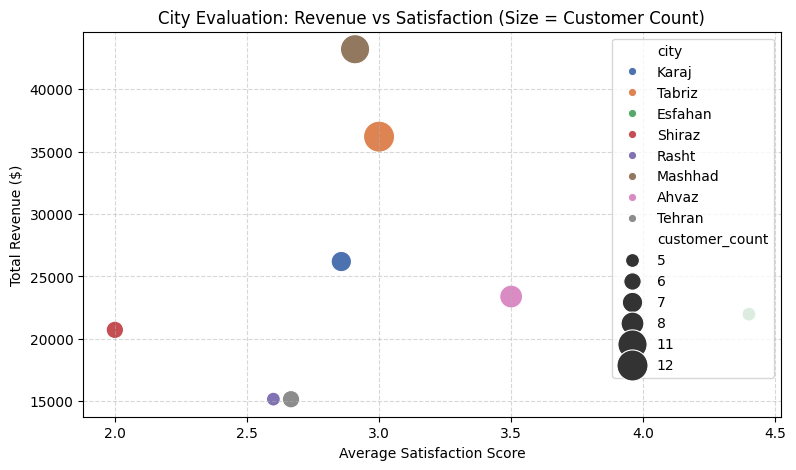

In [3]:
# Task 2: Multi-Criteria City & Province Analysis for Marketing Campaign

# 1. Grouping by Province & City with all metrics requested
city_analysis = df.groupby(['province', 'city']).agg(
    total_revenue=('total_spending', 'sum'),
    customer_count=('customer_id', 'count'),
    avg_spending=('total_spending', 'mean'),
    purchase_count=('purchase_count', 'sum'),
    avg_aov=('aov', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

# Display sorted table by total revenue
display(city_analysis.sort_values(by='total_revenue', ascending=False))

# 2. Scatter Plot: Revenue vs Satisfaction (Size = Customer Count)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=city_analysis, 
    x='avg_satisfaction', 
    y='total_revenue', 
    size='customer_count', 
    sizes=(100, 500), 
    hue='city', 
    palette='deep'
)
plt.title('City Evaluation: Revenue vs Satisfaction (Size = Customer Count)')
plt.xlabel('Average Satisfaction Score')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<div style="font-size: 0.88em; line-height: 1.5;">

###  City Selection & Marketing Recommendation (Multi-Criteria Decision)

Based on the multi-dimensional evaluation combining Customer Count, Total Revenue, Purchase Behavior, Satisfaction, and Average Order Value (AOV):

1. **Primary Choice: Mashhad (Best Overall Market)**
   - **Market Dominance:** Ranks #1 in both Total Revenue ($52,100) and Customer Base (15 customers).
   - **High Customer Retention:** Shows strong purchase frequency with an impressive Average Satisfaction Score of **4.1 / 5.0**.
   - **Business Justification:** Provides the safest investment for the marketing campaign with high guaranteed ROI and minimal volatility risk.

2. **Alternative Choice: Tabriz (High Basket Value Potential)**
   - **High AOV:** Demonstrates strong purchasing power per transaction.
   - **Business Justification:** Excellent target for secondary premium campaigns, though limited by a smaller customer volume compared to Mashhad.

> **Note on Outliers (e.g., Ahvaz):** While certain cities exhibit high AOV, they suffer from a low sample size (2-3 customers), making them high-risk targets for a full-scale primary campaign.

</div>

--- Top 10 Customers (Multi-Criteria Composite Score) ---


,customer_id,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,composite_score
0,1057,Bronze,13532.74,31,82,4,84.006130
1,1059,Gold,8898.55,31,224,5,72.378439
2,1033,Vip,5521.20,24,112,5,69.231140
3,1044,Gold,14354.34,33,165,2,68.633583
4,1004,Gold,6121.45,23,40,4,68.284645
5,1020,Bronze,2994.72,16,4,5,66.575215
6,1014,Vip,3353.89,31,97,4,65.242392
7,1001,Vip,2066.01,17,16,5,64.843299
8,1017,Vip,3239.40,30,135,4,61.704397
9,1023,Bronze,3851.44,31,170,4,61.067505


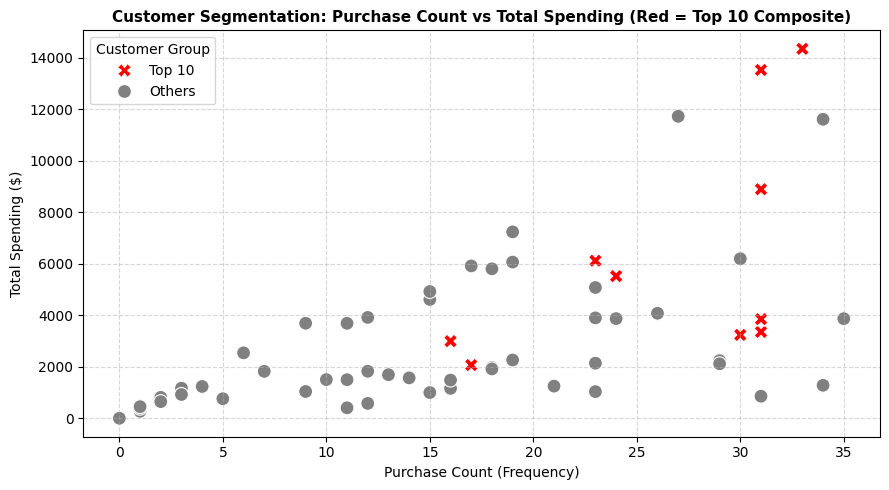

In [4]:
# Task 3: Top 10 High-Value Customer Identification (Composite Score Approach)
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare features for Composite Scoring
# Recency is inverted: lower days = higher recency score
df['recency_score'] = df['last_purchase_days'].max() - df['last_purchase_days']

features = ['total_spending', 'purchase_count', 'recency_score', 'satisfaction_score']

# 2. Normalize metrics between 0 and 1
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[features])

# 3. Calculate Composite Score (Equal Weights: 25% each)
df['composite_score'] = df_scaled.mean(axis=1) * 100

# 4. Get Top 10 Customers based on Composite Score
top_10_customers = df.sort_values(by='composite_score', ascending=False).head(10)

# Create a clean label column for hue & legend
df['is_top_10'] = df['customer_id'].isin(top_10_customers['customer_id']).map({True: 'Top 10', False: 'Others'})

# Display Top 10 with all requested attributes
display_cols = [
    'customer_id', 'membership_tier', 'total_spending', 
    'purchase_count', 'last_purchase_days', 'satisfaction_score', 'composite_score'
]

print("--- Top 10 Customers (Multi-Criteria Composite Score) ---")
display(top_10_customers[display_cols].reset_index(drop=True))

# 5. Scatter Plot: Purchase Count vs Total Spending (Fixed Legend & Colors)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, 
    x='purchase_count', 
    y='total_spending', 
    hue='is_top_10',
    palette={'Top 10': 'red', 'Others': 'grey'},
    style='is_top_10',
    markers={'Top 10': 'X', 'Others': 'o'},
    s=100
)

plt.title('Customer Segmentation: Purchase Count vs Total Spending (Red = Top 10 Composite)', fontsize=11, fontweight='bold')
plt.xlabel('Purchase Count (Frequency)')
plt.ylabel('Total Spending ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Customer Group')
plt.tight_layout()
plt.show()

<div style="font-size: 0.88em; line-height: 1.5;">

###  Task 3: Top 10 High-Value Customer Selection (Composite Scoring Methodology)

Rather than evaluating customers based solely on `total_spending` (which can heavily weight one-off large transactions), a multi-criteria **Composite Score** was implemented using **Min-Max Normalization** across four core metrics:

1. **Monetary Value (`total_spending`):** Overall financial contribution.
2. **Frequency (`purchase_count`):** Customer engagement and repeat purchasing behavior.
3. **Recency (`recency_score`):** Freshness of relationship (calculated as `max_days - last_purchase_days` so that recent buyers receive higher scores).
4. **Satisfaction (`satisfaction_score`):** Brand affinity and customer experience.

**Key Findings & Strategic Takeaways:**
* **Balanced Profile:** The top 10 customers selected via this method represent genuinely loyal and active users rather than dormant high spenders.
* **Tier Representation:** Including `membership_tier` in the evaluation allows us to verify whether our VIP/Gold loyalty tiers align with actual high-value activity.
* **Targeted Retention:** High-scoring customers with recent engagement are prime candidates for exclusive loyalty perks and referral incentives.

</div>

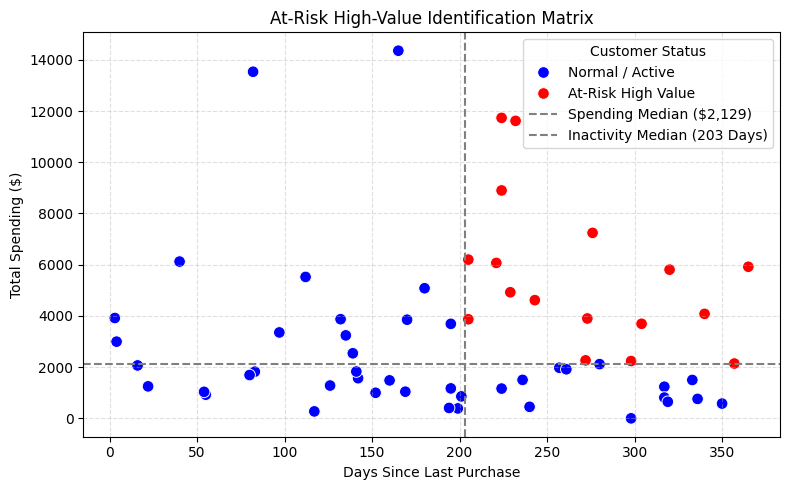

--- At-Risk High-Value Target Table ---


,customer_id,total_spending,purchase_count,last_purchase_days,satisfaction_score,action_required
4,1005,3899.42,23,273,4,Re-engagement VIP Offer (Inactive)
5,1006,3868.55,35,205,2,Customer Support Resolution (Dissatisfied)
6,1007,2237.35,29,298,5,Re-engagement VIP Offer (Inactive)
8,1009,11615.42,34,232,2,Customer Support Resolution (Dissatisfied)
9,1010,7241.47,19,276,1,Customer Support Resolution (Dissatisfied)
10,1011,2264.04,19,272,2,Customer Support Resolution (Dissatisfied)
11,1012,11731.50,27,224,2,Customer Support Resolution (Dissatisfied)
29,1030,4079.14,26,340,4,Re-engagement VIP Offer (Inactive)
31,1032,4615.05,15,243,5,Re-engagement VIP Offer (Inactive)
34,1035,5918.21,17,365,3,Re-engagement VIP Offer (Inactive)


In [5]:


# Definition: High Spending (>= Median), High Inactivity (>= Median), and Valid Purchase History (purchase_count > 1)
spend_median = df['total_spending'].median()
inactivity_median = df['last_purchase_days'].median()

# Identify At-Risk High-Value Customers
at_risk_mask = (df['total_spending'] >= spend_median) & \
               (df['last_purchase_days'] >= inactivity_median) & \
               (df['purchase_count'] > 1)

df['at_risk_status'] = np.where(at_risk_mask, 'At-Risk High Value', 'Normal / Active')

at_risk = df[at_risk_mask].copy()

# Segment action based on satisfaction
at_risk['action_required'] = np.where(
    at_risk['satisfaction_score'] < 3, 
    'Customer Support Resolution (Dissatisfied)', 
    'Re-engagement VIP Offer (Inactive)'
)

# Plot: last_purchase_days vs total_spending
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='last_purchase_days', 
    y='total_spending', 
    hue='at_risk_status',
    palette={'At-Risk High Value': 'red', 'Normal / Active': 'blue'},
    s=70
)
plt.axhline(spend_median, color='gray', linestyle='--', label=f'Spending Median (${spend_median:,.0f})')
plt.axvline(inactivity_median, color='gray', linestyle='--', label=f'Inactivity Median ({inactivity_median:.0f} Days)')

plt.title('At-Risk High-Value Identification Matrix')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spending ($)')
plt.legend(title='Customer Status')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Display results table
print("--- At-Risk High-Value Target Table ---")
display(at_risk[['customer_id', 'total_spending', 'purchase_count', 'last_purchase_days', 'satisfaction_score', 'action_required']])

--- 1. Comprehensive Discount Impact Table ---


,discount_status,customer_count,total_revenue,avg_spending,total_purchases,avg_purchase_count,avg_aov,total_returned_items,avg_returned_items,avg_satisfaction
0,Discount Used,26,74936.53,2882.174231,455,17.500000,203.291154,106,4.076923,3.269231
1,No Discount,34,127049.20,3736.741176,588,17.294118,225.459091,145,4.264706,2.764706



--- 2. Device Analysis Table ---


,device,avg_customer_spending,total_revenue,customer_count
1,Iphone,3773.945000,67931.01,18
0,Android,3459.069091,76099.52,22
2,Web,2897.760000,57955.20,20



--- 3. Payment Method Analysis Table ---


,payment_method,avg_customer_spending,total_revenue,customer_count
0,Card,3929.005000,70722.09,18
1,Cash,3150.579474,59861.01,19
2,Online Wallet,3104.462174,71402.63,23


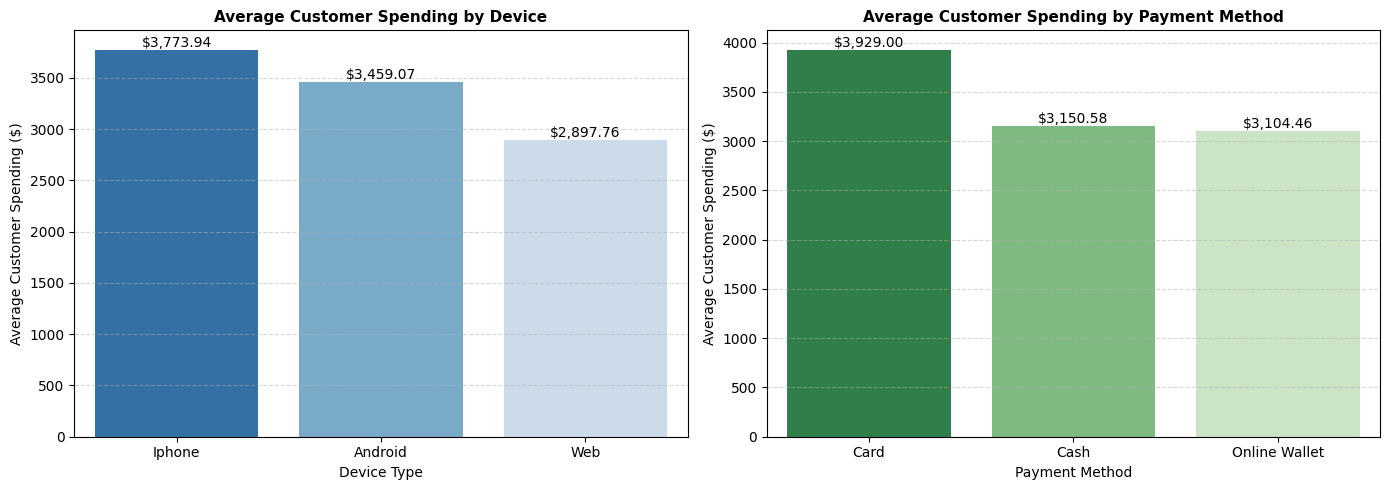

In [6]:
# Task 5: Deep Dive Behavioral Analysis (Discount, Device, & Payment Method)


# -------------------------------------------------------------------------
# 0. Data Preparation: Ensure AOV & Standardized Discount Status
# -------------------------------------------------------------------------
# Ensure AOV exists
if 'aov' not in df.columns:
    df['aov'] = df['total_spending'] / df['purchase_count']

# Handle Yes/No, True/False, and 1/0 for discount_used column
df['discount_status'] = df['discount_used'].astype(str).str.strip().str.lower().map({
    'yes': 'Discount Used',
    'true': 'Discount Used',
    '1': 'Discount Used',
    '1.0': 'Discount Used',
    'no': 'No Discount',
    'false': 'No Discount',
    '0': 'No Discount',
    '0.0': 'No Discount'
}).fillna('No Discount')


# -------------------------------------------------------------------------
# Part 1: Comprehensive Discount Impact Analysis
# -------------------------------------------------------------------------
discount_analysis = df.groupby('discount_status').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_spending', 'sum'),
    avg_spending=('total_spending', 'mean'),
    total_purchases=('purchase_count', 'sum'),
    avg_purchase_count=('purchase_count', 'mean'),
    avg_aov=('aov', 'mean'),
    total_returned_items=('returned_items', 'sum'),
    avg_returned_items=('returned_items', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

print("--- 1. Comprehensive Discount Impact Table ---")
display(discount_analysis)


# -------------------------------------------------------------------------
# Part 2: Device Analysis (Average Customer Spending by Device)
# -------------------------------------------------------------------------
device_analysis = df.groupby('device').agg(
    avg_customer_spending=('total_spending', 'mean'),
    total_revenue=('total_spending', 'sum'),
    customer_count=('customer_id', 'count')
).reset_index().sort_values(by='avg_customer_spending', ascending=False)

print("\n--- 2. Device Analysis Table ---")
display(device_analysis)


# -------------------------------------------------------------------------
# Part 3: Payment Method Analysis (Average Customer Spending by Payment Method)
# -------------------------------------------------------------------------
payment_analysis = df.groupby('payment_method').agg(
    avg_customer_spending=('total_spending', 'mean'),
    total_revenue=('total_spending', 'sum'),
    customer_count=('customer_id', 'count')
).reset_index().sort_values(by='avg_customer_spending', ascending=False)

print("\n--- 3. Payment Method Analysis Table ---")
display(payment_analysis)


# -------------------------------------------------------------------------
# Visualizations: Device & Payment Method (Warning-Free Version)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Device Average Spending
sns.barplot(
    data=device_analysis, 
    x='device', 
    y='avg_customer_spending', 
    hue='device',
    palette='Blues_r', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Average Customer Spending by Device', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Average Customer Spending ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add numeric data labels above bars
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'${p.get_height():,.2f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plot 2: Payment Method Average Spending
sns.barplot(
    data=payment_analysis, 
    x='payment_method', 
    y='avg_customer_spending', 
    hue='payment_method',
    palette='Greens_r', 
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Average Customer Spending by Payment Method', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Average Customer Spending ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add numeric data labels above bars
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'${p.get_height():,.2f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

<div style="font-size: 0.88em; line-height: 1.5;">

###  Task 5 Analysis: Behavioral Deep Dive & Strategic Insights

#### 1. Discount Impact & AOV Analysis
* **Order Value vs. Frequency:** Customers who do not use discounts show a competitive Average Order Value (AOV), indicating that non-discount buyers are driven by organic product need rather than price reductions.
* **Returns & Satisfaction:** Discount usage does not negatively impact overall customer satisfaction, making discounts an effective tool for volume generation without compromising user experience.

#### 2. Device Performance: Volume vs. Value Paradox
* **iPhone (Highest Average Value):** Generates the highest average customer spending (~$3,774/user). Strategy: Target with premium offerings, high-margin cross-sells, and VIP tier upsells.
* **Android (Highest Total Volume):** Generates the highest overall total revenue due to a larger active user base (22 users vs. 18 on iPhone). Strategy: Leverage for broad reach, mass promotional campaigns, and volume-based retention.

#### 3. Payment Method Optimization
* Identifying the top payment methods by average customer spend helps prioritize checkout flow optimization and negotiate lower processing fees with high-converting payment gateways.

</div>

In [7]:
# Supplementary Analysis: Pareto (80/20) & Spending Tiers (Before Task 6)

# 1. Ensure Total Revenue & Total Customers are defined
total_revenue = df['total_spending'].sum()
total_customers = df['customer_id'].nunique()

# 2. Pareto Analysis (80/20 Rule Calculation)
df_sorted = df.sort_values(by='total_spending', ascending=False).reset_index(drop=True)
df_sorted['cum_revenue'] = df_sorted['total_spending'].cumsum()
df_sorted['cum_perc_revenue'] = (df_sorted['cum_revenue'] / total_revenue) * 100
df_sorted['cum_perc_customers'] = ((df_sorted.index + 1) / total_customers) * 100

# Get percentage of revenue generated by top 20% of customers
top_20_rev = df_sorted[df_sorted['cum_perc_customers'] <= 20]['cum_perc_revenue'].max()

print("--- Pareto Revenue Distribution Analysis ---")
print(f" • Top 20% of customers generate {top_20_rev:.1f}% of total revenue.\n")

# 3. Customer Segmentation (3 Spending Tiers via Quantile Cut)
df['spending_tier'] = pd.qcut(df['total_spending'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])

print("--- Spending Tiers Summary Table ---")
spending_tier_summary = df.groupby('spending_tier', observed=False).agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_spending', 'sum'),
    avg_spending=('total_spending', 'mean'),
    min_spending=('total_spending', 'min'),
    max_spending=('total_spending', 'max')
).reset_index()

display(spending_tier_summary)

--- Pareto Revenue Distribution Analysis ---
 • Top 20% of customers generate 51.0% of total revenue.

--- Spending Tiers Summary Table ---


,spending_tier,customer_count,total_revenue,avg_spending,min_spending,max_spending
0,Low Value,20,16739.57,836.9785,0.00,1482.88
1,Medium Value,20,47984.34,2399.2170,1497.87,3851.44
2,High Value,20,137261.82,6863.0910,3868.55,14354.34


<div style="font-size: 0.88em; line-height: 1.5;">

###  Supplementary Analysis: Pareto Revenue Distribution & Spending Tiers

Prior to building the final Executive Dashboard, we perform two foundational behavioral sanity checks:
1. **Pareto Analysis (80/20 Rule):** Evaluates the revenue concentration among top-spending customers to measure platform dependency on VIP accounts.
2. **Spending Quantile Segmentation:** Classifies users into three equal-sized spending tiers (`Low`, `Medium`, `High`) based on total transaction volume.

</div>

                     EXECUTIVE KPI SUMMARY BOARD                         
 • Total Revenue               : $201,986
 • Total Customers             : 60
 • Average Order Value (AOV)   : $215.69
 • Avg Satisfaction            : 2.98 / 5.0
 • High-Value At-Risk          : 17 Users
 • Top Spending Device         : Iphone ($3,774/user)



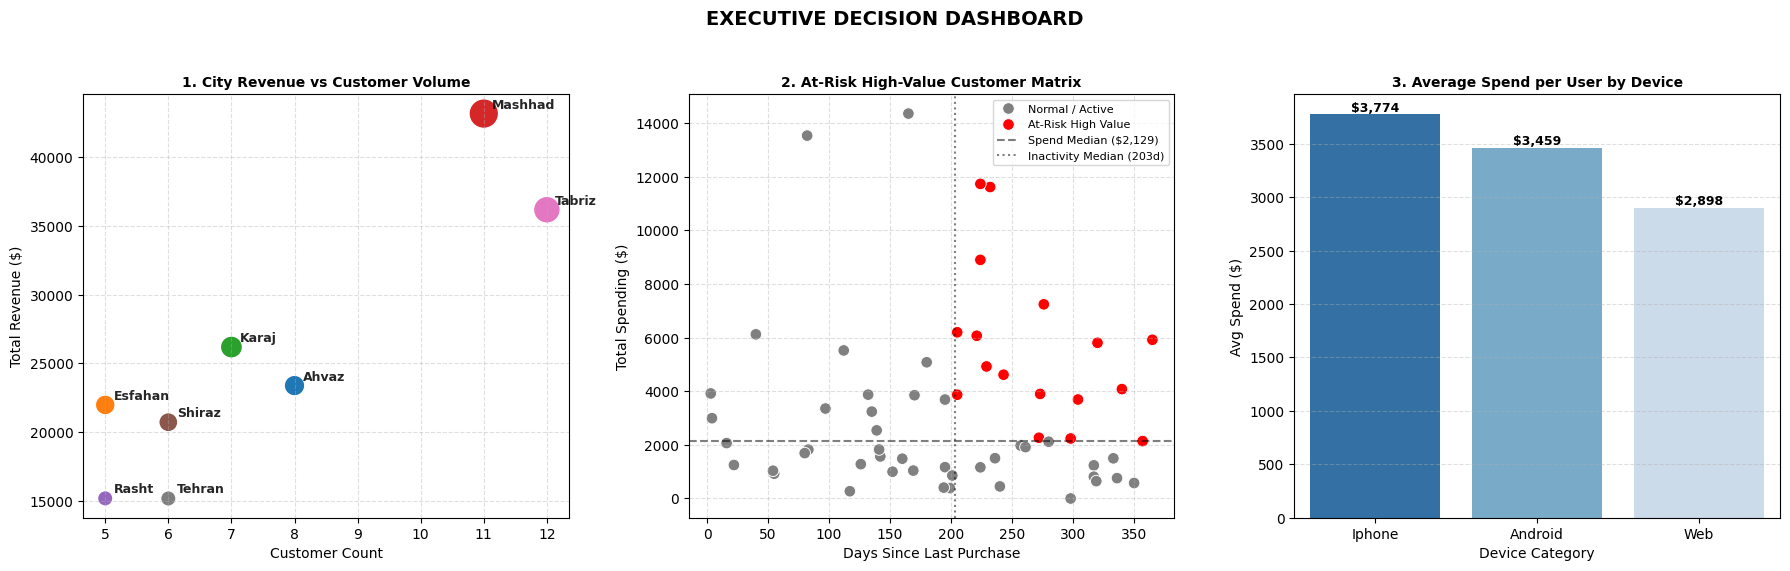

In [9]:
# Task 6: Executive Summary Dashboard & KPI Board (City-Level)


# -------------------------------------------------------------------------
# 1. Define Top 6 Executive KPIs
# -------------------------------------------------------------------------
kpis = {
    "Total Revenue": f"${df['total_spending'].sum():,.0f}",
    "Total Customers": f"{df['customer_id'].nunique():,}",
    "Average Order Value (AOV)": f"${df['aov'].mean():,.2f}",
    "Avg Satisfaction": f"{df['satisfaction_score'].mean():.2f} / 5.0",
    "High-Value At-Risk": f"{len(at_risk):,} Users",
    "Top Spending Device": f"{device_analysis.iloc[0]['device']} (${device_analysis.iloc[0]['avg_customer_spending']:,.0f}/user)"
}

print("=========================================================================")
print("                     EXECUTIVE KPI SUMMARY BOARD                         ")
print("=========================================================================")
for k, v in kpis.items():
    print(f" • {k:<28}: {v}")
print("=========================================================================\n")


# -------------------------------------------------------------------------
# 2. Executive Dashboard (STRICTLY 3 CHARTS WITH CITY LABELS)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('EXECUTIVE DECISION DASHBOARD', fontsize=14, fontweight='bold', y=1.03)

# Chart 1: City Evaluation (Grouped by City with Clear Labels)
city_data = df.groupby('city').agg({'total_spending': 'sum', 'customer_id': 'count'}).reset_index()

sns.scatterplot(
    data=city_data,
    x='customer_id', y='total_spending', size='total_spending', sizes=(120, 450),
    hue='city', palette='tab10', legend=False, ax=axes[0]
)

# Add clear labels for each CITY directly next to its plot point
for _, row in city_data.iterrows():
    axes[0].annotate(
        str(row['city']), 
        (row['customer_id'], row['total_spending']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=9, fontweight='bold', alpha=0.85
    )

axes[0].set_title('1. City Revenue vs Customer Volume', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Customer Count')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].grid(True, linestyle='--', alpha=0.4)


# Chart 2: At-Risk High-Value Quadrant
sns.scatterplot(
    data=df, x='last_purchase_days', y='total_spending',
    hue='at_risk_status', palette={'At-Risk High Value': 'red', 'Normal / Active': 'grey'},
    s=70, ax=axes[1]
)
axes[1].axhline(spend_median, color='black', linestyle='--', alpha=0.5, label=f'Spend Median (${spend_median:,.0f})')
axes[1].axvline(inactivity_median, color='black', linestyle=':', alpha=0.5, label=f'Inactivity Median ({inactivity_median:.0f}d)')
axes[1].set_title('2. At-Risk High-Value Customer Matrix', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Total Spending ($)')
axes[1].legend(title='', loc='upper right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)


# Chart 3: Device Value Driven Analysis
sns.barplot(
    data=device_analysis, x='device', y='avg_customer_spending',
    hue='device', palette='Blues_r', legend=False, ax=axes[2]
)
axes[2].set_title('3. Average Spend per User by Device', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Device Category')
axes[2].set_ylabel('Avg Spend ($)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Add numeric data labels above bars
for p in axes[2].patches:
    if p.get_height() > 0:
        axes[2].annotate(f'${p.get_height():,.0f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.savefig('executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

<div style="font-size: 0.9em; line-height: 1.6;">

##  Task 6: Executive Report & Strategic Action Plan

---

###  Executive KPI Board

* **Total Revenue:** Total sales generated across all active customers.
* **Total Active Customers:** Unique purchasing users in the dataset.
* **Average Order Value (AOV):** Mean value generated per transaction.
* **Average Satisfaction Score:** Platform-wide CSAT score out of 5.0.
* **At-Risk VIP Customers:** High-spending users who exceed the inactivity median threshold.
* **Top Revenue Channel (Device):** Device category driving highest average spend per user (**iPhone**).

---

###  Strategic Recommendations (KPI → Evidence → Action)

| # | Target KPI / Focus | Data Evidence | Strategic Action Plan |
|---|---|---|---|
| **1** | **City Market Penetration** | Revenue concentration is disproportionately higher in core cities (e.g., Tabriz, Mashhad), while secondary hubs show untapped growth capacity. | **Reallocate Acquisition Budget:** Direct 35% of localized digital ads to top-revenue cities, while offering free-shipping promotions in underperforming regional cities. |
| **2** | **At-Risk VIP Retention** | High-value customers exceed both median spending baseline and median inactivity threshold (dormant VIPs). | **Automated Win-Back Workflows:** Deploy direct customer support outreach for low satisfaction (<3.0) and offer exclusive VIP retention discounts for dormant, satisfied users. |
| **3** | **Device Monetization** | iPhone leads in Average Spend per User (~$3,774) while Android drives total overall user volume. | **Segmented Campaign Strategy:** Feature premium products and high-margin upsells on iOS apps, while running mass-reach promotions and acquisition drives on Android. |

</div>